# Scenario: Modelling a Scale

![Precision scale with calibration weights](images/scale.jpg)

The quality assurance department of a scale producer needs to certify the error of its precision scales to be within a certain bound (with high certainty). For this purpose, 

- a number of weight measurements $y$ of normed weights $x$ is performed for each scale, 
- based on which the its absolute error $e = y - x$ and relative error $\tilde{e}=e / x$ is assessed using statistical data analysis. 

## Variant 1: Unbiased Scale

For example, the measurements for a scale could be as follows.

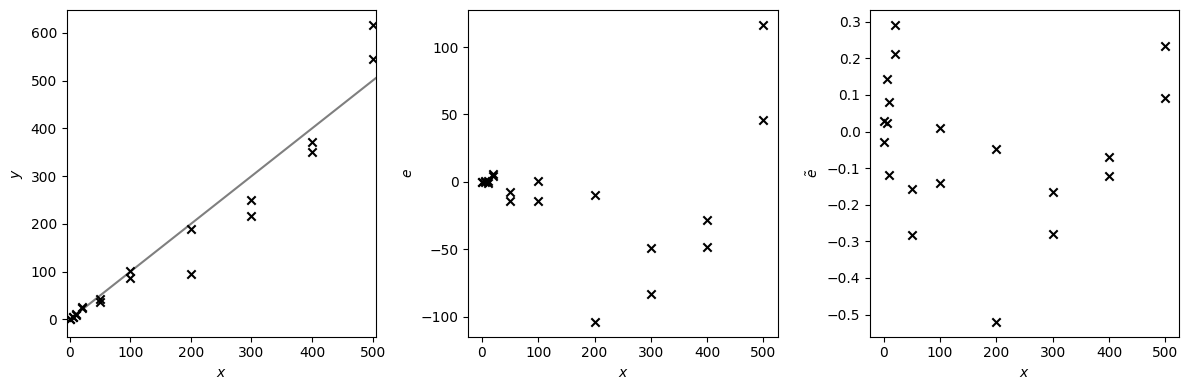

In [7]:
from scenarios import scale_measurements
from matplotlib import pyplot as plt

sigma2=0.05
x, y = scale_measurements(variance=sigma2, seed=0)
n = len(x)
errors = y - x
rel_errors = errors / x
_, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
axs[0].plot([-5, 505], [-5, 505], color='black', alpha=.5)
axs[0].margins(x=0)
axs[0].scatter(x, y, marker='x', color='black'); axs[0].set_xlabel('$x$'); axs[0].set_ylabel('$y$')
axs[1].scatter(x, errors, marker='x', color='black'); axs[1].set_xlabel('$x$'); axs[1].set_ylabel('$e$')
axs[2].scatter(x, rel_errors, marker='x', color='black'); axs[2].set_xlabel('$x$'); axs[2].set_ylabel(r'$\tilde{e}$')
plt.show()

Based on the physical design of the scale, the following normal model for the scale measurements is plausible:
$$
y \mid \sigma^2, x \sim N(x, (x\sigma)^2) \enspace .
$$
That is, the measurements are unbiased with an unknown noise variance that increases with the square of the true weight.

**Questions**

Based on this model...

1. what is the distribution of the absolute and relative measurement errors?
2. what is the likelihood function for estimates of $\sigma^2$ using the relative error distribution?



**Answers**

The absolute and relative errors are simply shifted and scaled variants of $y$. By applying the standard formulas for shifting end scaling, we see that:
$$
\begin{aligned}
e &\mid \sigma^2 \sim N(0, (x\sigma)^2)\\
\tilde{e} &\mid \sigma^2 \sim N(0, \sigma^2) \enspace .
\end{aligned}
$$
This results in the following log likelihood function:
$$
\begin{aligned}
\log p(\tilde{\boldsymbol{e}} \mid \sigma^2) &= \log \prod_{i=1}^n \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left(-\frac{\tilde{e}_i^2}{2\sigma^2}\right) \\
&= -\frac{n}{2}\log \sigma^2 - \frac{\sum_{i=1}^n \tilde{e}^2_i}{2\sigma^2} - \frac{n}{2}\log 2\pi
\end{aligned}
$$

$$
\begin{aligned}
\frac{\mathrm{d}}{\mathrm{d}\sigma^2} \log p(\tilde{\boldsymbol{e}} \mid \sigma^2) = -\frac{n}{2\sigma^2} + \frac{2\sum \tilde{e}^2_i}{4\sigma^4}
\end{aligned}
$$

$$
\sigma^2_\mathrm{ML} = \sum_{i=1}^n \tilde{e}^2/n
$$

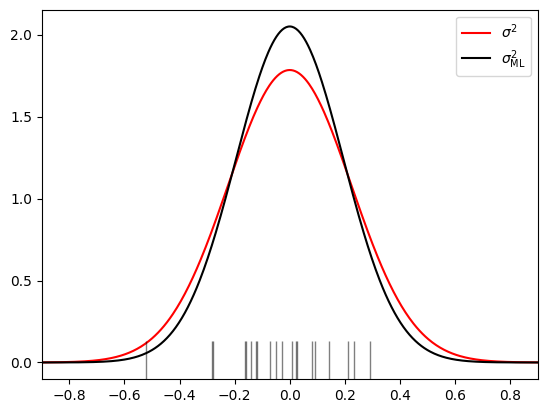

In [6]:
import numpy as np
from scipy.stats import norm

sigma2_ml = (rel_errors**2).mean()

xx = np.linspace(-0.9, 0.9, 500)
plt.plot(xx, norm.pdf(xx, scale=sigma2**0.5), label=r'$\sigma^2$', color='red')
plt.plot(xx, norm.pdf(xx, scale=sigma2_ml**0.5), label=r'$\sigma^2_\mathrm{ML}$', color='black')
plt.plot(rel_errors, np.zeros_like(rel_errors), '|k', markersize=30, alpha=0.5)
plt.margins(x=0)
plt.legend()
plt.show()

To construct a conjugate prior we analyse the likelihood function 
$$
p(\tilde{\boldsymbol{e}} \mid \sigma^2) \propto (\sigma^2)^{-n/2}\exp\left(-\frac{\sum_{i=1}^n\tilde{e}^2_i}{2\sigma^2}\right)
$$
and see that the form
$$
p(\sigma^2 \mid a, b) \propto (\sigma^2)^a \exp \left( \frac{b}{\sigma^2} \right)
$$
is retained in the unnormalised posterior
$$
p(\tilde{\boldsymbol{e}} \mid \sigma^2) p(\sigma^2 \mid a, b) = 
$$

Investigating the catalogue of common distributions we see that this pattern matches the inverse gamma distribution, i.e., we can choose $\sigma^2 \mid \alpha, \beta \sim \mathrm{InvGamma}(\alpha, \beta)$ with the exact pdf
$$
p(\sigma^2 \mid \alpha, \beta) = \frac{\beta^\alpha}{\Gamma(\alpha)} (\sigma^2)^{-\alpha-1} \exp\left(-\frac{\beta}{\sigma^2} \right)
$$

$$
\begin{aligned}
p(\sigma^2 \mid \boldsymbol{y}) & \propto \exp()\\
& = \left( \sigma^2 \right)^{-\alpha - n/2 -1} \exp\left(-\frac{\beta + \sum_{i=1}^n \tilde{e}_i^2 /2}{\sigma^2}\right)
\end{aligned}
$$

21.0 0.8691542174522101


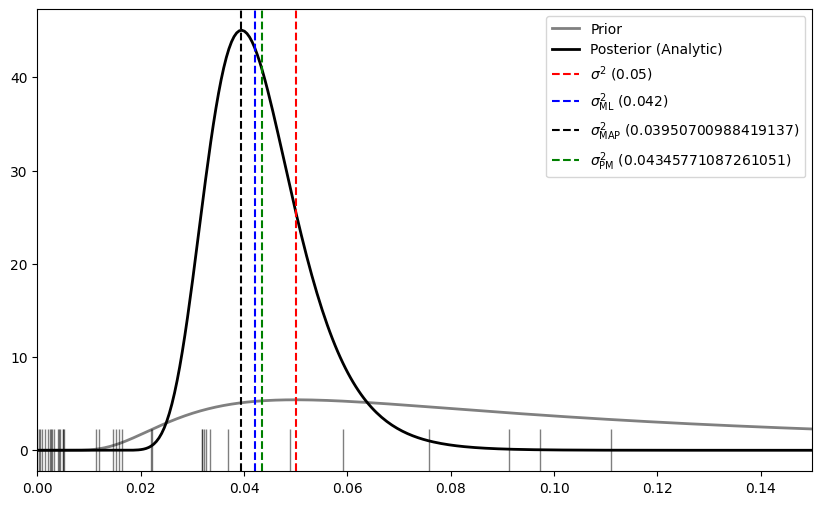

In [62]:
import numpy as np
from scipy.stats import invgamma

alpha_prior = 1.0
beta_prior = 0.1

alpha_post = alpha_prior + len(rel_errors) / 2.0
beta_post = beta_prior + np.sum(rel_errors**2) / 2.0
sigma2_map = beta_post / (alpha_post + 1)
sigma2_post_mean = beta_post / (alpha_post - 1)

print(alpha_post, beta_post)

plt.figure(figsize=(10, 6))

x = np.linspace(0.0, 0.25, 500)
plt.plot(x, invgamma.pdf(x, alpha_prior, scale=beta_prior), 
         color='gray', linewidth=2, label='Prior')
plt.plot(x, invgamma.pdf(x, alpha_post, scale=beta_post), 
         color='black', linewidth=2, label='Posterior (Analytic)')
plt.axvline(sigma2, color='red', linestyle='--', label=f'$\\sigma^2$ ({sigma2})')
plt.axvline(sigma2_ml, color='blue', linestyle='--', label=f'$\\sigma^2_\\mathrm{{ML}}$ ({sigma2_ml:.3f})')
plt.axvline(sigma2_map, color='black', linestyle='--', label=f'$\\sigma^2_\\mathrm{{MAP}}$ ({sigma2_map})')
plt.axvline(sigma2_post_mean, color='green', linestyle='--', label=f'$\\sigma^2_\\mathrm{{PM}}$ ({sigma2_post_mean})')
plt.plot(rel_errors**2, np.zeros_like(rel_errors), '|k', markersize=30, alpha=0.5)
plt.legend()
plt.margins(x=0)
plt.xlim(0, 0.15)
plt.show()


## Variant 2: Unknown Mean and Variance

$$
y \mid \mu, \sigma^2, x \sim \mathrm{N}(x(1+\mu), (x\sigma)^2)
$$

In [1]:
mean = 0.1
x2, y2 = scale_measurements(mean=mean, variance=sigma2, seed=0, reps_per_weight=5)
errors2 = y2 - x2
rel_errors2 = errors2 / x2
_, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
xx = np.array([-5, 505])
axs[0].plot(xx, xx, color='black', alpha=.5)
axs[0].plot(xx, xx*(1.+mean), color='red', alpha=.5)
axs[0].margins(x=0)
axs[0].scatter(x2, y2, marker='x', color='black'); axs[0].set_xlabel('$x$'); axs[0].set_ylabel('$y$')
axs[1].scatter(x2, errors2, marker='x', color='black'); axs[1].set_xlabel('$x$'); axs[1].set_ylabel('$e$')
axs[2].scatter(x2, rel_errors2, marker='x', color='black'); axs[2].set_xlabel('$x$'); axs[2].set_ylabel(r'$\tilde{e}$')
plt.show()
print(rel_errors2**2)

NameError: name 'scale_measurements' is not defined

$$
p(\boldsymbol{e} \mid \mu, \sigma^2) \propto (\sigma^2)^{-n/2} \exp\left(-\frac{\sum_{i=1}^n(\tilde{e}_i - \mu)^2}{2\sigma^2}\right)
$$

$$
\begin{aligned}
\mu \mid \sigma^2 &\sim N(0, \sigma^2)\\
\sigma^2 &\sim \mathrm{InvGamma}(\alpha, \beta)
\end{aligned}
$$

### Posterior Distribution

$$
\begin{aligned}
\sigma^2 \mid \boldsymbol{y} &\sim \mathrm{InvGamma}\left (\alpha + \frac{n}{2}, \beta + \frac{1}{2}\left(\mathrm{SSE}+\frac{n\nu}{n + \nu}\left(\overline{\boldsymbol{y}}-\mu_0\right)^2\right)\right)\\
\mu \mid \sigma^2, \boldsymbol{y} &\sim \mathrm{N}\left(\frac{n}{n + \nu}\overline{\boldsymbol{y}} + \frac{\nu}{n+\nu}\mu_0, \frac{\sigma^2}{n + \nu}\right)
\end{aligned}
$$

In [ ]:
n = len(rel_errors2)
mu_ml = np.mean(rel_errors2)
sigma2_ml = np.var(rel_errors2)

# Prior (Weak)
mu_0, nu_0 = 0.0, 1.0  
alpha_0, beta_0 = 1.0, 0.1

# Posterior
nu_post = nu_0 + n
alpha_post = alpha_0 + n / 2.0
mu_n = (nu_0 * mu_0 + n * mu_ml) / nu_n
sse = np.sum((rel_errors2 - mu_ml)**2)
beta_n = beta_0 + 0.5 * sse + (n * nu_0 / (nu_n)) * 0.5 * (mu_ml - mu_0)**2

post_mode_mu = mu_n
post_mode_sigma2 = beta_n / (alpha_n + 1.5)

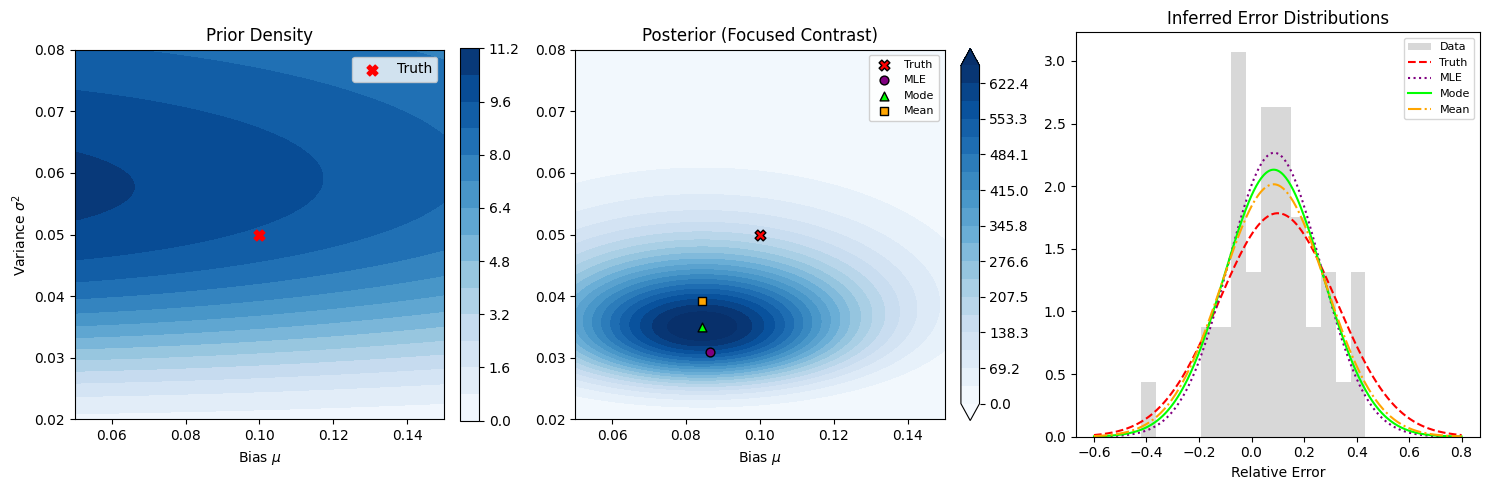

In [35]:
import matplotlib.pyplot as plt
from scipy.stats import invgamma, norm
import numpy as np

# --- 1. Grid & Density Calculation ---
def nig_pdf(mu, sig2, m, v, a, b):
    if sig2 <= 0: return 0.0
    return invgamma.pdf(sig2, a, scale=b) * norm.pdf(mu, loc=m, scale=np.sqrt(sig2 / v))

mu_grid = np.linspace(0.05, 0.15, 200)
sig2_grid = np.linspace(0.02, 0.08, 200)
X, Y = np.meshgrid(mu_grid, sig2_grid)

Z_prior = np.zeros_like(X)
Z_post = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z_prior[i, j] = nig_pdf(X[i, j], Y[i, j], mu_0, nu_0, alpha_0, beta_0)
        Z_post[i, j] = nig_pdf(X[i, j], Y[i, j], mu_n, nu_n, alpha_n, beta_n)

# Estimates
post_mean_mu = mu_n
post_mean_sigma2 = beta_n / (alpha_n - 1)

# --- 2. Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cmap_style = 'Blues'

# --- Plot 1: Prior ---
cs1 = axes[0].contourf(X, Y, Z_prior, levels=15, cmap=cmap_style)
axes[0].set_title(r'Prior Density')
axes[0].set_xlabel(r'Bias $\mu$')
axes[0].set_ylabel(r'Variance $\sigma^2$')
axes[0].scatter(mean, sigma2, color='red', marker='X', s=60, label='Truth')
fig.colorbar(cs1, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].legend(loc='upper right')

# --- Plot 2: Posterior (Dual Clipping) ---
# We define the "Region of Interest" for colors
z_max = Z_post.max()
vmin_post = z_max * 0.0  # Clip bottom 5% (Ignore tails)
vmax_post = z_max * 0.95  # Clip top 40% (Saturate peak)
levels_post = np.linspace(vmin_post, vmax_post, 20)

cs2 = axes[1].contourf(X, Y, Z_post, levels=levels_post, cmap=cmap_style, extend='both')
axes[1].set_title(r'Posterior (Focused Contrast)')
axes[1].set_xlabel(r'Bias $\mu$')

# Markers
axes[1].scatter(mean, sigma2, c='red', marker='X', s=60, ec='k', label='Truth')
axes[1].scatter(mle_mu, mle_sigma2, c='purple', marker='o', s=40, ec='k', label='MLE')
axes[1].scatter(post_mode_mu, post_mode_sigma2, c='lime', marker='^', s=40, ec='k', label='Mode')
axes[1].scatter(post_mean_mu, post_mean_sigma2, c='orange', marker='s', s=40, ec='k', label='Mean')

fig.colorbar(cs2, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].legend(loc='upper right', framealpha=0.9, fontsize=8)

# --- Plot 3: Response ---
x_dist = np.linspace(-0.6, 0.8, 300)
axes[2].hist(rel_errors, bins=15, density=True, alpha=0.3, color='gray', label='Data')
axes[2].plot(x_dist, norm.pdf(x_dist, mean, np.sqrt(sigma2)), 'r--', label='Truth')
axes[2].plot(x_dist, norm.pdf(x_dist, mle_mu, np.sqrt(mle_sigma2)), 'purple', ls=':', label='MLE')
axes[2].plot(x_dist, norm.pdf(x_dist, post_mode_mu, np.sqrt(post_mode_sigma2)), 'lime', label='Mode')
axes[2].plot(x_dist, norm.pdf(x_dist, post_mean_mu, np.sqrt(post_mean_sigma2)), 'orange', ls='-.', label='Mean')

axes[2].set_title('Inferred Error Distributions')
axes[2].set_xlabel('Relative Error')
axes[2].legend(loc='upper right', fontsize=8)

for ax in axes: ax.set_box_aspect(1)
plt.tight_layout()
plt.show()

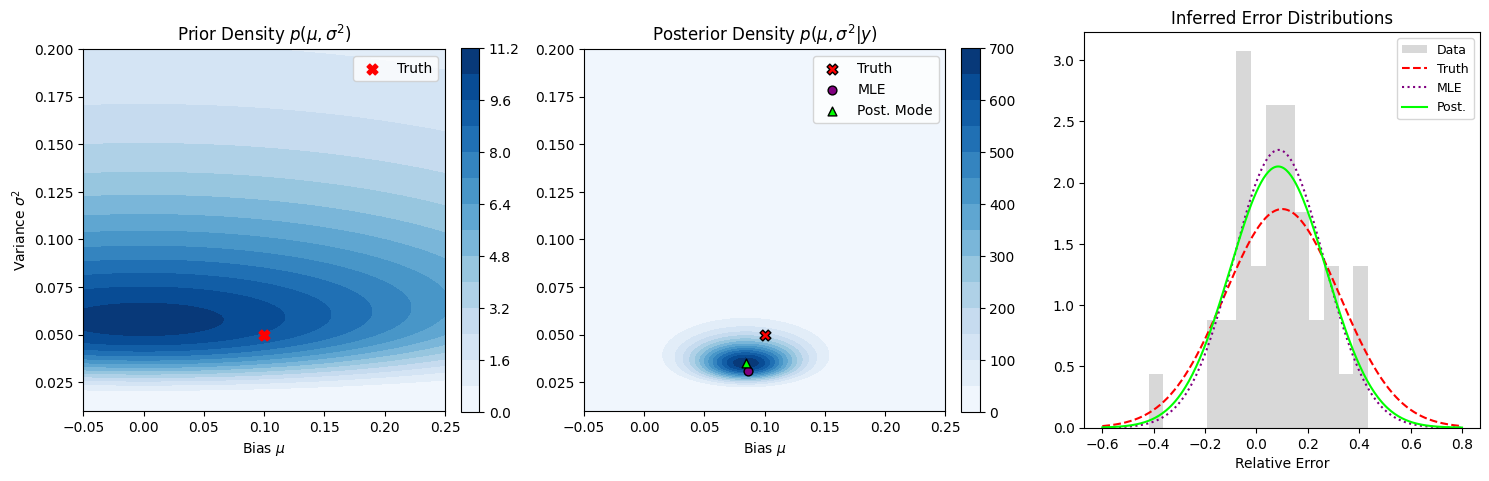

In [22]:
import matplotlib.pyplot as plt
from scipy.stats import invgamma, norm

# --- 1. Grid & Density Calculation ---
# We recalculate Z values here to ensure the plotting block is self-contained
# regarding visualization logic.

def nig_pdf(mu, sig2, m, v, a, b):
    if sig2 <= 0: return 0.0
    return invgamma.pdf(sig2, a, scale=b) * norm.pdf(mu, loc=m, scale=np.sqrt(sig2 / v))

# Define Grid (Focused on relevant region)
mu_grid = np.linspace(-0.05, 0.25, 200)
sig2_grid = np.linspace(0.01, 0.20, 200)
X, Y = np.meshgrid(mu_grid, sig2_grid)

Z_prior = np.zeros_like(X)
Z_post = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z_prior[i, j] = nig_pdf(X[i, j], Y[i, j], mu_0, nu_0, alpha_0, beta_0)
        Z_post[i, j] = nig_pdf(X[i, j], Y[i, j], mu_n, nu_n, alpha_n, beta_n)

# --- 2. Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Common styling
cmap_style = 'Blues'

# --- Plot 1: Prior (Linear Scale, Independent Range) ---
# We let contourf determine the levels automatically based on Z_prior's own min/max
cs1 = axes[0].contourf(X, Y, Z_prior, levels=15, cmap=cmap_style)
axes[0].set_title(r'Prior Density $p(\mu, \sigma^2)$')
axes[0].set_xlabel(r'Bias $\mu$')
axes[0].set_ylabel(r'Variance $\sigma^2$')
axes[0].scatter(mean, sigma2, color='red', marker='X', s=60, label='Truth')
# Colorbar shows the low absolute values
fig.colorbar(cs1, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].legend(loc='upper right')

# --- Plot 2: Posterior (Linear Scale, Independent Range) ---
# Z_post values are much higher, so we let it scale independently
cs2 = axes[1].contourf(X, Y, Z_post, levels=15, cmap=cmap_style)
axes[1].set_title(r'Posterior Density $p(\mu, \sigma^2 | y)$')
axes[1].set_xlabel(r'Bias $\mu$')
# axes[1].set_ylabel(r'Variance $\sigma^2$') # Shared visual axis
axes[1].scatter(mean, sigma2, c='red', marker='X', s=60, ec='k', label='Truth')
axes[1].scatter(mle_mu, mle_sigma2, c='purple', marker='o', s=40, ec='k', label='MLE')
axes[1].scatter(post_mode_mu, post_mode_sigma2, c='lime', marker='^', s=40, ec='k', label='Post. Mode')
# Colorbar shows the high absolute values
fig.colorbar(cs2, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].legend(loc='upper right')

# --- Plot 3: Response Distributions ---
x_dist = np.linspace(-0.6, 0.8, 300)
axes[2].hist(rel_errors, bins=15, density=True, alpha=0.3, color='gray', label='Data')
axes[2].plot(x_dist, norm.pdf(x_dist, mean, np.sqrt(sigma2)), 'r--', label='Truth')
axes[2].plot(x_dist, norm.pdf(x_dist, mle_mu, np.sqrt(mle_sigma2)), 'purple', ls=':', label='MLE')
axes[2].plot(x_dist, norm.pdf(x_dist, post_mode_mu, np.sqrt(post_mode_sigma2)), 'lime', label='Post.')
axes[2].set_title('Inferred Error Distributions')
axes[2].set_xlabel('Relative Error')
axes[2].legend(loc='upper right', fontsize=9)

# Enforce Square Aspect Ratio
for ax in axes: ax.set_box_aspect(1)

plt.tight_layout()
plt.show()

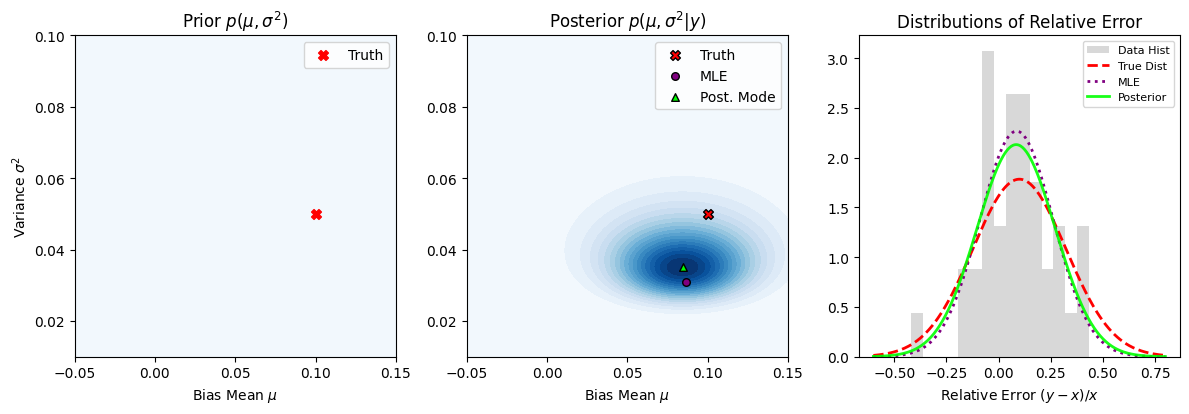

In [19]:
n = len(rel_errors)

# 2. Inference (NIG Model)
# MLE
mle_mu = np.mean(rel_errors)
mle_sigma2 = np.var(rel_errors)

# Prior (Weak)
mu_0, nu_0 = 0.0, 1.0  
alpha_0, beta_0 = 2.0, 0.2

# Posterior
nu_n = nu_0 + n
alpha_n = alpha_0 + n / 2.0
mu_n = (nu_0 * mu_0 + n * mle_mu) / nu_n
sse = np.sum((rel_errors - mle_mu)**2)
beta_n = beta_0 + 0.5 * sse + (n * nu_0 / (nu_n)) * 0.5 * (mle_mu - mu_0)**2

post_mode_mu = mu_n
post_mode_sigma2 = beta_n / (alpha_n + 1.5)

# 3. Grid Setup for Contours
def nig_pdf(mu, sig2, m, v, a, b):
    if sig2 <= 0: return 0.0
    p_sig2 = invgamma.pdf(sig2, a, scale=b)
    p_mu = norm.pdf(mu, loc=m, scale=np.sqrt(sig2 / v))
    return p_sig2 * p_mu

# Tighter limits as requested
mu_grid = np.linspace(-0.05, 0.15, 200)
sig2_grid = np.linspace(0.01, 0.10, 200)
X, Y = np.meshgrid(mu_grid, sig2_grid)

Z_prior = np.zeros_like(X)
Z_post = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z_prior[i, j] = nig_pdf(X[i, j], Y[i, j], mu_0, nu_0, alpha_0, beta_0)
        Z_post[i, j] = nig_pdf(X[i, j], Y[i, j], mu_n, nu_n, alpha_n, beta_n)

# Define Common Levels based on Posterior Max (to unify color scale)
max_z = Z_post.max()
levels = np.linspace(0, max_z, 20)

# 4. Visualization
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Common Marker Style
markers = [
    (true_mu, true_sigma2, 'red', 'X', 50, 'Truth'),
    (mle_mu, mle_sigma2, 'purple', 'o', 30, 'MLE'),
    (post_mode_mu, post_mode_sigma2, 'lime', '^', 30, 'Post. Mode')
]

# --- Plot 1: Prior ---
# Uses same 'levels' as posterior. Will look faint/diffuse, which is correct.
axes[0].contourf(X, Y, Z_prior, levels=levels, cmap='Blues', extend='max')
axes[0].set_title(r'Prior $p(\mu, \sigma^2)$')
axes[0].set_xlabel(r'Bias Mean $\mu$')
axes[0].set_ylabel(r'Variance $\sigma^2$')
axes[0].set_aspect('auto') # 'equal' can be tricky with different axis scales, keeping square shape via figure

# Add markers (Truth only meaningful one here)
axes[0].scatter(true_mu, true_sigma2, color='red', marker='X', s=50, label='Truth')
axes[0].legend(loc='upper right')

# --- Plot 2: Posterior ---
cs = axes[1].contourf(X, Y, Z_post, levels=levels, cmap='Blues', extend='max')
axes[1].set_title(r'Posterior $p(\mu, \sigma^2 | y)$')
axes[1].set_xlabel(r'Bias Mean $\mu$')
# Shared Y axis, but we label it for clarity
# axes[1].set_ylabel(r'Variance $\sigma^2$') 

# Add all markers
for x, y, c, m, s, l in markers:
    axes[1].scatter(x, y, color=c, marker=m, s=s, edgecolor='k', label=l)
axes[1].legend(loc='upper right')

# --- Plot 3: Response Distributions ---
x_dist = np.linspace(-0.6, 0.8, 300)
axes[2].hist(rel_errors, bins=15, density=True, alpha=0.3, color='gray', label='Data Hist')
axes[2].plot(x_dist, norm.pdf(x_dist, true_mu, np.sqrt(true_sigma2)), 
             'r--', linewidth=2, label=r'True Dist')
axes[2].plot(x_dist, norm.pdf(x_dist, mle_mu, np.sqrt(mle_sigma2)), 
             'purple', linestyle=':', linewidth=2, label='MLE')
axes[2].plot(x_dist, norm.pdf(x_dist, post_mode_mu, np.sqrt(post_mode_sigma2)), 
             'lime', linestyle='-', linewidth=2, alpha=0.9, label='Posterior')

axes[2].set_title('Distributions of Relative Error')
axes[2].set_xlabel(r'Relative Error $(y-x)/x$')
axes[2].legend(loc='upper right', fontsize=8)

# Enforce Square Aspect Ratio for first two plots visually
axes[0].set_box_aspect(1)
axes[1].set_box_aspect(1)
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.show()

/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_81080/442118655.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


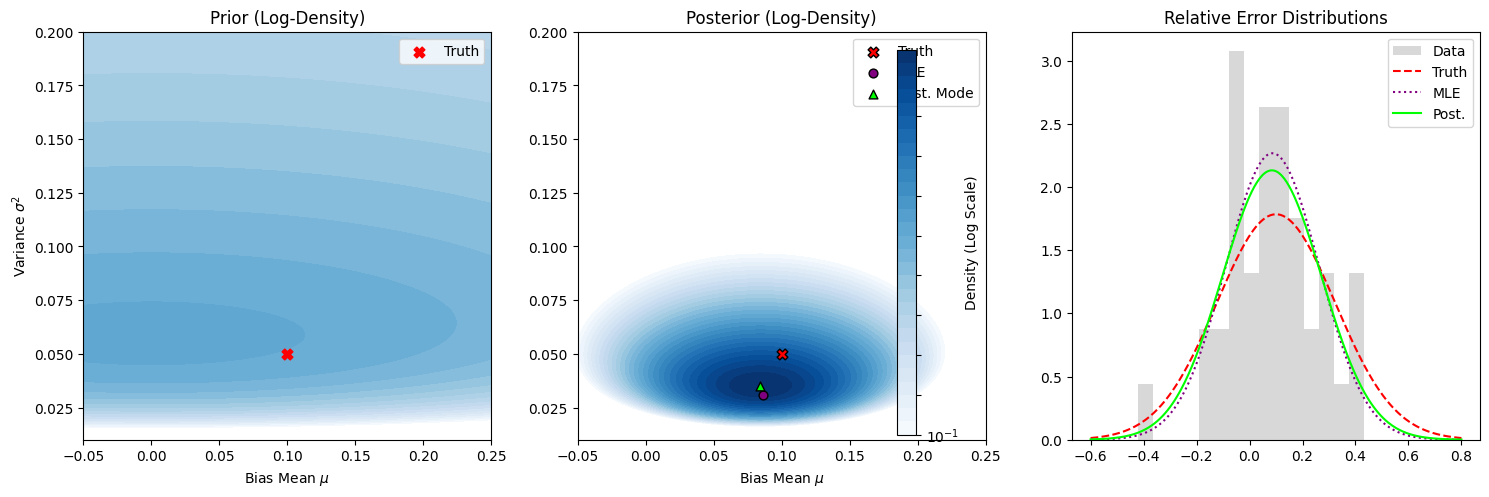

In [21]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# --- Helper: PDF Calculation ---
def nig_pdf(mu_val, sig2_val, m, v, a, b):
    # Returns P(sigma2) * P(mu | sigma2)
    if sig2_val <= 0: return 1e-300
    p_sig2 = invgamma.pdf(sig2_val, a, scale=b)
    p_mu = norm.pdf(mu_val, loc=m, scale=np.sqrt(sig2_val / v))
    return p_sig2 * p_mu

# --- 1. Grid Setup ---
mu_grid = np.linspace(-0.05, 0.25, 200)
sig2_grid = np.linspace(0.01, 0.20, 200)
X, Y = np.meshgrid(mu_grid, sig2_grid)

Z_prior = np.zeros_like(X)
Z_post = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z_prior[i, j] = nig_pdf(X[i, j], Y[i, j], mu_0, nu_0, alpha_0, beta_0)
        Z_post[i, j] = nig_pdf(X[i, j], Y[i, j], mu_n, nu_n, alpha_n, beta_n)

# --- 2. Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Dynamic Range for Log Scale (Unified)
vmin = 1e-1 
vmax = Z_post.max()
levels = np.logspace(np.log10(vmin), np.log10(vmax), 30)

# Plot 1: Prior
axes[0].contourf(X, Y, Z_prior, levels=levels, norm=LogNorm(vmin=vmin, vmax=vmax), cmap='Blues')
axes[0].set_title(r'Prior (Log-Density)')
axes[0].set_xlabel(r'Bias Mean $\mu$')
axes[0].set_ylabel(r'Variance $\sigma^2$')
axes[0].scatter(mean, sigma2, color='red', marker='X', s=60, label='Truth')
axes[0].legend(loc='upper right')

# Plot 2: Posterior
cs = axes[1].contourf(X, Y, Z_post, levels=levels, norm=LogNorm(vmin=vmin, vmax=vmax), cmap='Blues')
axes[1].set_title(r'Posterior (Log-Density)')
axes[1].set_xlabel(r'Bias Mean $\mu$')
# Markers
axes[1].scatter(mean, sigma2, c='red', marker='X', s=60, label='Truth', ec='k')
axes[1].scatter(mle_mu, mle_sigma2, c='purple', marker='o', s=40, label='MLE', ec='k')
axes[1].scatter(post_mode_mu, post_mode_sigma2, c='lime', marker='^', s=40, label='Post. Mode', ec='k')
axes[1].legend(loc='upper right')

# Plot 3: Response Distributions
x_dist = np.linspace(-0.6, 0.8, 300)
axes[2].hist(rel_errors, bins=15, density=True, alpha=0.3, color='gray', label='Data')
axes[2].plot(x_dist, norm.pdf(x_dist, mean, np.sqrt(sigma2)), 'r--', label='Truth')
axes[2].plot(x_dist, norm.pdf(x_dist, mle_mu, np.sqrt(mle_sigma2)), 'purple', ls=':', label='MLE')
axes[2].plot(x_dist, norm.pdf(x_dist, post_mode_mu, np.sqrt(post_mode_sigma2)), 'lime', label='Post.')
axes[2].set_title('Relative Error Distributions')
axes[2].legend(loc='upper right')

# Colorbar & Styling
fig.colorbar(cs, ax=axes[:2], fraction=0.05, label='Density (Log Scale)')
for ax in axes: ax.set_box_aspect(1)

plt.tight_layout()
plt.show()

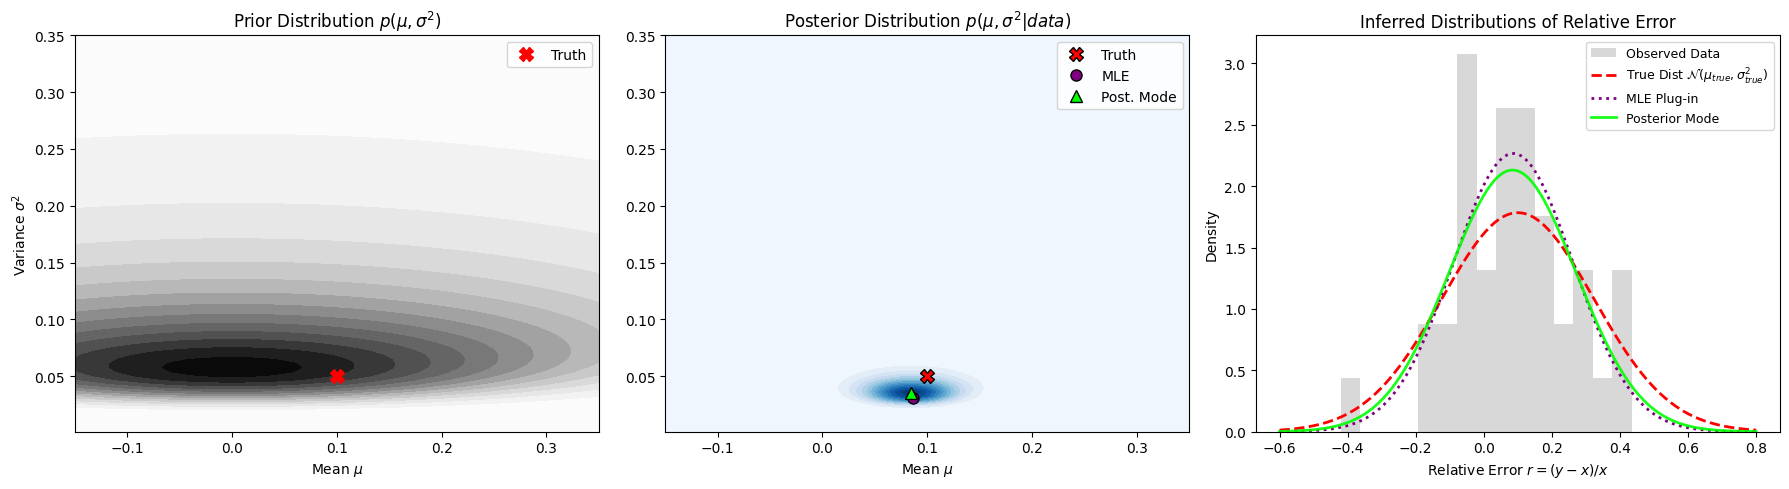

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma, norm

# 1. Data Generation Function
def scale_measurements(weights=np.array([1, 5, 10, 20, 50, 100, 200, 500]),
                       reps_per_weight=2,
                       mean=0.0,
                       variance=0.05,
                       seed=None):
    seed = seed or 0
    x = np.repeat(weights, reps_per_weight)
    rng = np.random.default_rng(seed=seed)
    y = rng.normal(x * (1 + mean), x * np.sqrt(variance))
    return x, y

# 2. Generate Data
true_mu = 0.1
true_sigma2 = 0.05
x_data, y_data = scale_measurements(mean=true_mu, variance=true_sigma2, seed=0, reps_per_weight=5)

# Transform to relative errors
rel_errors = (y_data - x_data) / x_data
n = len(rel_errors)

# 3. Inference Statistics
# MLE
mle_mu = np.mean(rel_errors)
mle_sigma2 = np.var(rel_errors) # Population variance (div by n)

# Prior Parameters (NIG)
mu_0, nu_0 = 0.0, 1.0  
alpha_0, beta_0 = 2.0, 0.2

# Posterior Parameters
nu_n = nu_0 + n
alpha_n = alpha_0 + n / 2.0
mu_n = (nu_0 * mu_0 + n * mle_mu) / nu_n

# Beta update: prior_beta + data_sse/2 + conflict_term
sse = np.sum((rel_errors - mle_mu)**2)
beta_n = beta_0 + 0.5 * sse + (n * nu_0 / (nu_n)) * 0.5 * (mle_mu - mu_0)**2

# Point Estimates
post_mean_mu = mu_n
post_mean_sigma2 = beta_n / (alpha_n - 1)

post_mode_mu = mu_n
post_mode_sigma2 = beta_n / (alpha_n + 1.5)

# 4. Visualization Setup
def nig_pdf(mu, sig2, m, v, a, b):
    # P(sigma2) * P(mu | sigma2)
    if sig2 <= 0: return 0.0
    p_sig2 = invgamma.pdf(sig2, a, scale=b)
    p_mu = norm.pdf(mu, loc=m, scale=np.sqrt(sig2 / v))
    return p_sig2 * p_mu

# Grid for Contours
mu_grid = np.linspace(-0.15, 0.35, 100)
sig2_grid = np.linspace(0.001, 0.35, 100)
X, Y = np.meshgrid(mu_grid, sig2_grid)

Z_prior = np.zeros_like(X)
Z_post = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z_prior[i, j] = nig_pdf(X[i, j], Y[i, j], mu_0, nu_0, alpha_0, beta_0)
        Z_post[i, j] = nig_pdf(X[i, j], Y[i, j], mu_n, nu_n, alpha_n, beta_n)

# 5. Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Common styling for contour plots
param_markers = [
    (true_mu, true_sigma2, 'red', 'X', 10, 'Truth'),
    (mle_mu, mle_sigma2, 'purple', 'o', 8, 'MLE'),
    (post_mode_mu, post_mode_sigma2, 'lime', '^', 8, 'Post. Mode')
]

# --- Plot 1: Prior ---
# We use independent color scaling because Prior density is much lower than Posterior
cs1 = axes[0].contourf(X, Y, Z_prior, levels=15, cmap='Greys')
axes[0].set_title(r'Prior Distribution $p(\mu, \sigma^2)$')
axes[0].set_xlabel(r'Mean $\mu$')
axes[0].set_ylabel(r'Variance $\sigma^2$')
axes[0].plot(true_mu, true_sigma2, 'rX', markersize=10, label='Truth') # Only show truth on prior
axes[0].legend()

# --- Plot 2: Posterior ---
cs2 = axes[1].contourf(X, Y, Z_post, levels=15, cmap='Blues')
axes[1].set_title(r'Posterior Distribution $p(\mu, \sigma^2 | data)$')
axes[1].set_xlabel(r'Mean $\mu$')
# axes[1].set_ylabel(r'Variance $\sigma^2$') # Shared y-axis visually

# Add markers to Posterior
for x, y, c, m, s, l in param_markers:
    axes[1].plot(x, y, color=c, marker=m, markersize=s, linestyle='None', markeredgecolor='k', label=l)
axes[1].legend()

# --- Plot 3: Response Distributions (Relative Errors) ---
x_dist = np.linspace(-0.6, 0.8, 200)

# A. Histogram of Data
axes[2].hist(rel_errors, bins=15, density=True, alpha=0.3, color='gray', label='Observed Data')

# B. True Distribution
axes[2].plot(x_dist, norm.pdf(x_dist, true_mu, np.sqrt(true_sigma2)), 
             'r--', linewidth=2, label=r'True Dist $\mathcal{N}(\mu_{true}, \sigma^2_{true})$')

# C. MLE Plug-in
axes[2].plot(x_dist, norm.pdf(x_dist, mle_mu, np.sqrt(mle_sigma2)), 
             'purple', linestyle=':', linewidth=2, label='MLE Plug-in')

# D. Posterior Mode Plug-in
axes[2].plot(x_dist, norm.pdf(x_dist, post_mode_mu, np.sqrt(post_mode_sigma2)), 
             'lime', linestyle='-', linewidth=2, alpha=0.9, label='Posterior Mode')

axes[2].set_title('Inferred Distributions of Relative Error')
axes[2].set_xlabel(r'Relative Error $r = (y-x)/x$')
axes[2].set_ylabel('Density')
axes[2].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\s'
<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_81080/1023515687.py:83: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Bias Mean ($\mu$)')
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_81080/1023515687.py:84: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('Error Variance ($\sigma^2$)')


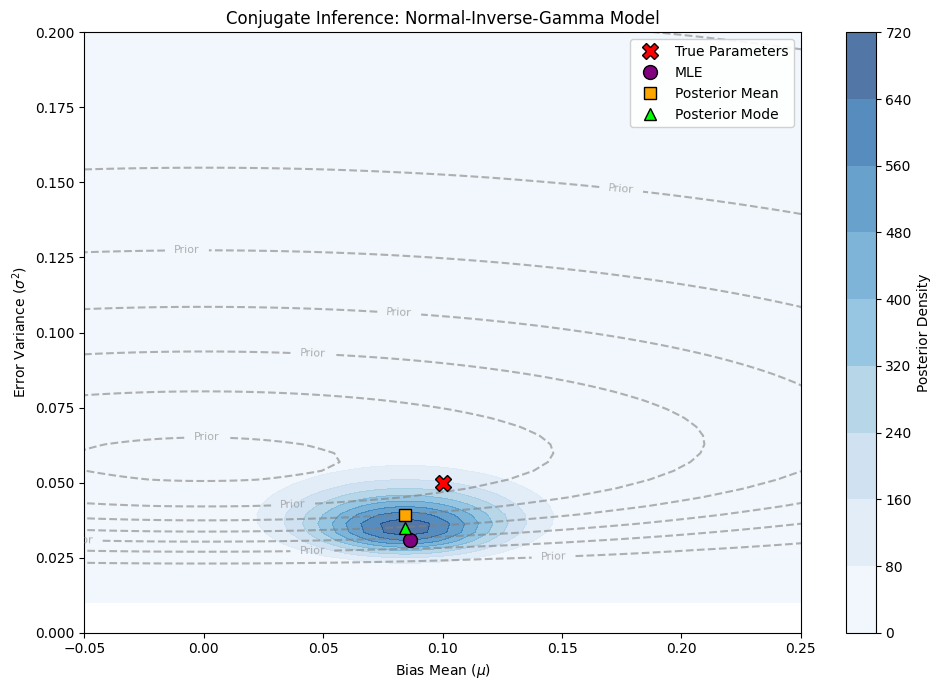

In [15]:
from scipy.stats import norm

n = len(rel_errors2)

# 3. Calculate Sufficient Statistics
data_mean = np.mean(rel_errors2)
# MLE for variance (population variance formula)
data_sse = np.sum((rel_errors2 - data_mean)**2) 
mle_sigma2 = data_sse / n
mle_mu = data_mean

# 4. Bayesian Inference (NIG Model)
# Prior Parameters (Weakly informative)
# We guess bias ~ 0, but with low confidence
mu_0, nu_0 = 0.0, 1.0  
alpha_0, beta_0 = 2.0, 0.2 # Expecting variance around 0.2 / (2-1) = 0.2

# Posterior Parameters
nu_n = nu_0 + n
alpha_n = alpha_0 + n / 2.0
mu_n = (nu_0 * mu_0 + n * data_mean) / (nu_n)

# Beta Update: Prior Beta + Data SSE + Conflict Term
beta_n = beta_0 + 0.5 * data_sse + (n * nu_0 / (n + nu_0)) * 0.5 * (data_mean - mu_0)**2

# 5. Point Estimates
# Posterior Mean: E[sigma2] = beta/(alpha-1), E[mu] = mu_n
post_mean_sigma2 = beta_n / (alpha_n - 1)
post_mean_mu = mu_n

# Posterior Mode (Joint Mode): mu = mu_n, sigma2 = beta / (alpha + 1.5)
post_mode_sigma2 = beta_n / (alpha_n + 1.5)
post_mode_mu = mu_n

# 6. Visualization Helpers
def nig_pdf(mu, sig2, m, v, a, b):
    # P(sigma2) * P(mu | sigma2)
    if sig2 <= 0: return 0
    p_sig2 = invgamma.pdf(sig2, a, scale=b)
    p_mu = norm.pdf(mu, loc=m, scale=np.sqrt(sig2 / v))
    return p_sig2 * p_mu

# Create Grid
mu_grid = np.linspace(-0.1, 0.3, 100)
sig2_grid = np.linspace(0.01, 0.3, 100)
X, Y = np.meshgrid(mu_grid, sig2_grid)

# Calculate Densities
Z_prior = np.zeros_like(X)
Z_post = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z_prior[i, j] = nig_pdf(X[i, j], Y[i, j], mu_0, nu_0, alpha_0, beta_0)
        Z_post[i, j] = nig_pdf(X[i, j], Y[i, j], mu_n, nu_n, alpha_n, beta_n)

# 7. Plotting
fig, ax = plt.subplots(figsize=(10, 7))

# Contour Plots
# Prior in Grays (Background)
cnt_prior = ax.contour(X, Y, Z_prior, levels=8, colors='gray', linestyles='--', alpha=0.6)
ax.clabel(cnt_prior, inline=True, fontsize=8, fmt='Prior')

# Posterior in Blues (Foreground)
cnt_post = ax.contourf(X, Y, Z_post, levels=10, cmap='Blues', alpha=0.7)
fig.colorbar(cnt_post, ax=ax, label='Posterior Density')

# Markers for Estimates
markers = [
    (mean, sigma2, 'red', 'X', 12, 'True Parameters'),
    (mle_mu, mle_sigma2, 'purple', 'o', 10, 'MLE'),
    (post_mean_mu, post_mean_sigma2, 'orange', 's', 9, 'Posterior Mean'),
    (post_mode_mu, post_mode_sigma2, 'lime', '^', 9, 'Posterior Mode'),
]

for x, y, color, marker, size, label in markers:
    ax.plot(x, y, color=color, marker=marker, markersize=size, 
            markeredgecolor='black', linestyle='None', label=label)

# Final Polish
ax.set_title('Conjugate Inference: Normal-Inverse-Gamma Model')
ax.set_xlabel('Bias Mean ($\mu$)')
ax.set_ylabel('Error Variance ($\sigma^2$)')
ax.legend(loc='upper right', framealpha=0.9)
ax.set_xlim(-0.05, 0.25)
ax.set_ylim(0, 0.2)

plt.tight_layout()
plt.show()

## Gemini Raw Outputs

10.0 0.5459300087160976


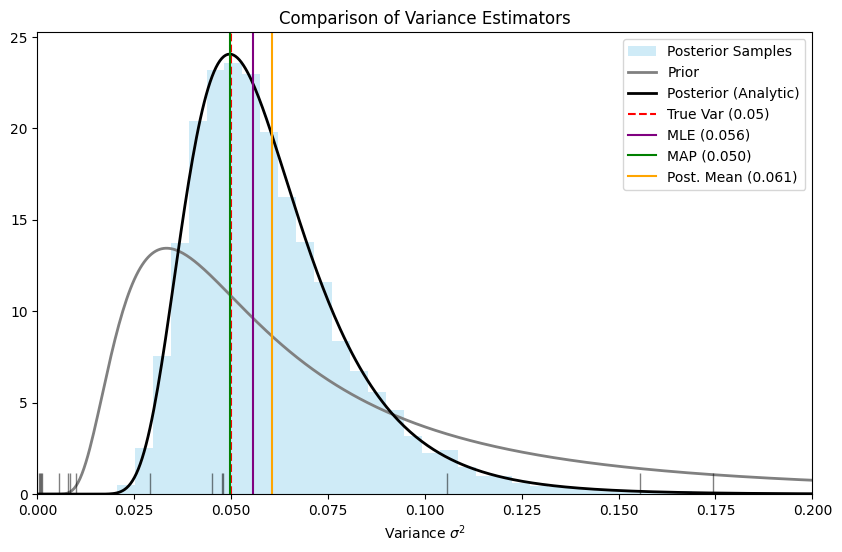

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# 1. Setup Data
np.random.seed(0)
true_weights = np.array([1, 5, 10, 20, 50, 100, 200, 500]) 
true_mus = np.repeat(true_weights, 2) 
true_sigma2 = 0.05
readings = np.random.normal(true_mus, np.sqrt(true_sigma2))
squared_errors = (readings - true_mus)**2

# 2. Inference
alpha_prior = 2.0
beta_prior = 0.1

alpha_post = alpha_prior + len(squared_errors) / 2.0
beta_post = beta_prior + np.sum(squared_errors) / 2.0

print(alpha_post, beta_post)

# 3. Calculate Estimators
# Posterior Mean: beta / (alpha - 1)
post_mean = beta_post / (alpha_post - 1)
# Posterior Mode (MAP): beta / (alpha + 1)
post_map = beta_post / (alpha_post + 1)
# MLE: sum(errors^2) / n
mle = np.mean(squared_errors)

# 4. Sampling
posterior_samples = invgamma.rvs(alpha_post, scale=beta_post, size=10000)

# 5. Visualization
plt.figure(figsize=(10, 6))

# A. Histogram of Samples
plt.hist(posterior_samples, bins=60, density=True, alpha=0.4, color='skyblue', label='Posterior Samples')

# B. Analytic PDF Curves
x = np.linspace(0.0, 0.25, 500)
plt.plot(x, invgamma.pdf(x, alpha_prior, scale=beta_prior), 
         color='gray', linewidth=2, label='Prior')
plt.plot(x, invgamma.pdf(x, alpha_post, scale=beta_post), 
         color='black', linewidth=2, label='Posterior (Analytic)')

# C. Estimator Lines
plt.axvline(true_sigma2, color='red', linestyle='--', label=f'True Var ({true_sigma2})')
plt.axvline(mle, color='purple', linestyle='-', linewidth=1.5, label=f'MLE ({mle:.3f})')
plt.axvline(post_map, color='green', linestyle='-', linewidth=1.5, label=f'MAP ({post_map:.3f})')
plt.axvline(post_mean, color='orange', linestyle='-', linewidth=1.5, label=f'Post. Mean ({post_mean:.3f})')

# D. Data (Rug Plot)
plt.plot(squared_errors, np.zeros_like(squared_errors), '|k', markersize=30, alpha=0.5)

plt.xlabel(r"Variance $\sigma^2$")
plt.legend()
plt.xlim(0, 0.2)
plt.title("Comparison of Variance Estimators")
plt.show()

Acceptance Rate: 60.96% (Target usually 20-50%)


<>:102: SyntaxWarning: invalid escape sequence '\s'
<>:102: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_72294/264071174.py:102: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Variance $\sigma^2$")


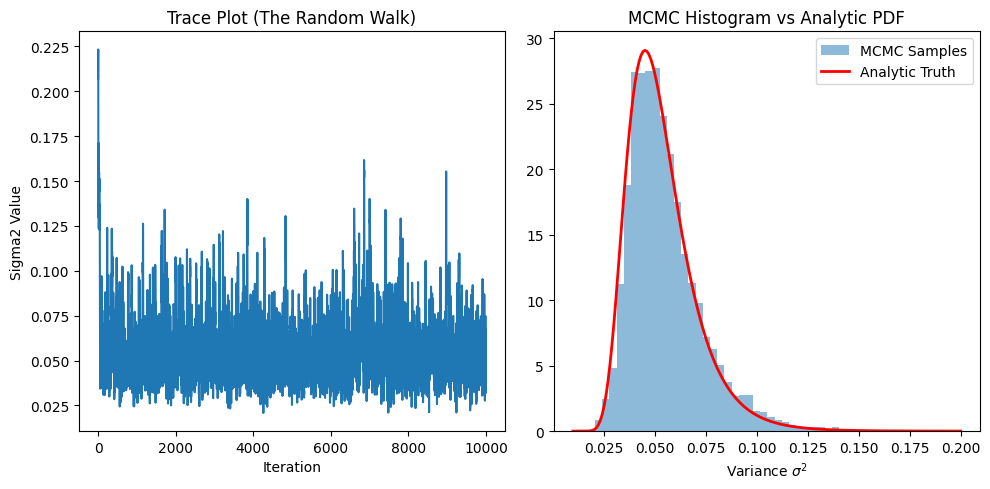

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma, norm

# 1. Setup Data (Same as before)
np.random.seed(2026)
n_samples = 20
true_sigma2 = 0.05
# We assume we have already transformed to errors ~ N(0, sigma2)
errors = np.random.normal(0, np.sqrt(true_sigma2), size=n_samples)
squared_errors = errors**2

# Prior Parameters
alpha_prior = 2.0
beta_prior = 0.1

# ---------------------------------------------------------
# 2. Define the Unnormalized Posterior (in Log Space)
# ---------------------------------------------------------
def log_prior(sigma2):
    if sigma2 <= 0: return -np.inf # Impossible region
    # Log pdf of Inverse Gamma
    return invgamma.logpdf(sigma2, alpha_prior, scale=beta_prior)

def log_likelihood(sigma2, data_squared_errors):
    if sigma2 <= 0: return -np.inf
    n = len(data_squared_errors)
    # Log Likelihood of N(0, sigma^2)
    # -n/2 * log(2*pi*sigma^2) - sum(e^2)/(2*sigma^2)
    return - (n/2) * np.log(2 * np.pi * sigma2) - np.sum(data_squared_errors) / (2 * sigma2)

def log_posterior_unnorm(sigma2, data):
    lp = log_prior(sigma2)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(sigma2, data)

# ---------------------------------------------------------
# 3. Metropolis-Hastings Sampler
# ---------------------------------------------------------
def metropolis_hastings(n_iterations, initial_sigma2, proposal_width):
    samples = []
    current_sigma2 = initial_sigma2
    current_log_prob = log_posterior_unnorm(current_sigma2, squared_errors)
    
    accepted = 0
    
    for i in range(n_iterations):
        # A. Propose a new value (Gaussian random walk)
        proposal = current_sigma2 + np.random.normal(0, proposal_width)
        
        # B. Calculate acceptance probability
        # Note: If proposal <= 0, log_prob returns -inf, ensuring rejection
        proposal_log_prob = log_posterior_unnorm(proposal, squared_errors)
        
        # Ratio in log space is subtraction
        log_accept_ratio = proposal_log_prob - current_log_prob
        
        # C. Accept/Reject Step
        # We accept if log_ratio > 0 (prob > 1) 
        # OR if log(random_uniform) < log_ratio
        if np.log(np.random.rand()) < log_accept_ratio:
            current_sigma2 = proposal
            current_log_prob = proposal_log_prob
            accepted += 1
            
        samples.append(current_sigma2)
        
    return np.array(samples), accepted / n_iterations

# ---------------------------------------------------------
# 4. Run Sampling
# ---------------------------------------------------------
# Tuning: 'proposal_width' determines how far we jump. 
# Too small = slow exploration. Too large = high rejection rate.
n_iter = 10000
samples_mcmc, acc_rate = metropolis_hastings(n_iter, initial_sigma2=0.2, proposal_width=0.02)

print(f"Acceptance Rate: {acc_rate:.2%} (Target usually 20-50%)")

# 5. Visualization
plt.figure(figsize=(10, 5))

# Plot Trace (The "Walk")
plt.subplot(1, 2, 1)
plt.plot(samples_mcmc)
plt.title("Trace Plot (The Random Walk)")
plt.xlabel("Iteration")
plt.ylabel("Sigma2 Value")

# Plot Histogram vs Analytic Truth
plt.subplot(1, 2, 2)
plt.hist(samples_mcmc[1000:], bins=40, density=True, alpha=0.5, label='MCMC Samples') # Burn-in 1000

# Overlay Analytic Posterior (The "Truth" we derived earlier)
alpha_post = alpha_prior + n_samples / 2.0
beta_post = beta_prior + np.sum(squared_errors) / 2.0
x = np.linspace(0.01, 0.2, 200)
plt.plot(x, invgamma.pdf(x, alpha_post, scale=beta_post), 'r-', linewidth=2, label='Analytic Truth')

plt.title("MCMC Histogram vs Analytic PDF")
plt.xlabel("Variance $\sigma^2$")
plt.legend()
plt.tight_layout()
plt.show()

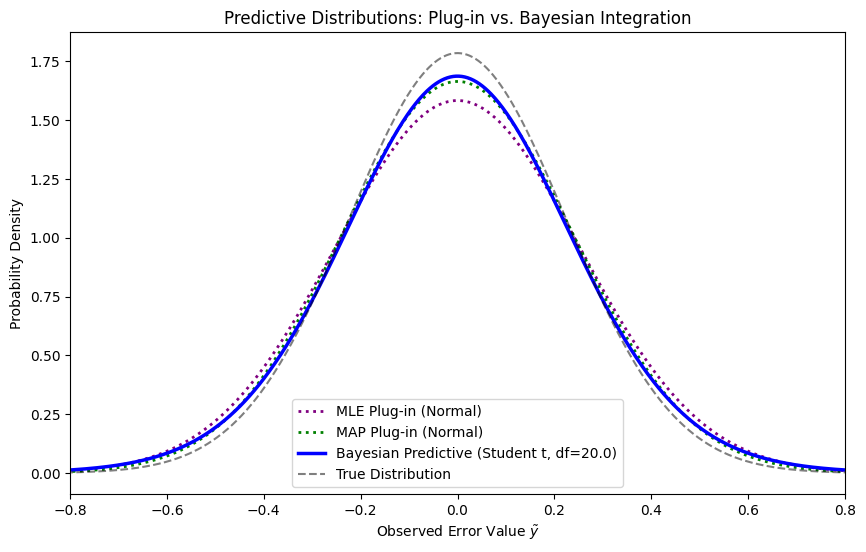

In [19]:
# ... assuming alpha_post, beta_post, mle_var, map_var are in memory ...

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# 1. Define Predictive Distributions based on Previous Inference
# A. MLE (Plug-in): Normal(0, MLE_Variance)
dist_mle = norm(loc=0, scale=np.sqrt(mle_var))

# B. MAP (Plug-in): Normal(0, MAP_Variance)
dist_map = norm(loc=0, scale=np.sqrt(map_var))

# C. Bayesian (Marginalized): Student-t(df=2*alpha_post, scale=sqrt(beta_post/alpha_post))
# We use the posterior parameters directly. No priors involved.
df_pred = 2 * alpha_post
scale_pred = np.sqrt(beta_post / alpha_post)
dist_bayes = t(df=df_pred, loc=0, scale=scale_pred)

# 2. Visualization
x_grid = np.linspace(-1.0, 1.0, 1000)

plt.figure(figsize=(10, 6))

# Plot Densities
plt.plot(x_grid, dist_mle.pdf(x_grid), 'purple', linestyle=':', linewidth=2, label='MLE Plug-in (Normal)')
plt.plot(x_grid, dist_map.pdf(x_grid), 'green', linestyle=':', linewidth=2, label='MAP Plug-in (Normal)')
plt.plot(x_grid, dist_bayes.pdf(x_grid), 'blue', linewidth=2.5, label=f'Bayesian Predictive (Student t, df={df_pred:.1f})')
plt.plot(x_grid, norm.pdf(x_grid, 0, np.sqrt(true_sigma2)), 'k--', alpha=0.5, label='True Distribution')

plt.title("Predictive Distributions: Plug-in vs. Bayesian Integration")
plt.xlabel(r"Observed Error Value $\tilde{y}$")
plt.ylabel("Probability Density")
plt.legend()
plt.xlim(-0.8, 0.8)
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_72294/3565104419.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.hist(posterior_samples, bins=50, density=True, alpha=0.6, label='Posterior $\sigma^2$')
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_72294/3565104419.py:35: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Error Variance ($\sigma^2$)")


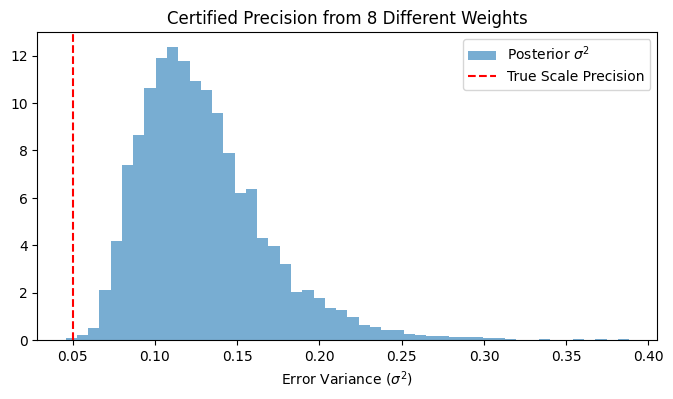

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# 1. Setup: A Calibration Set of different true weights
np.random.seed(42)
true_weights = np.array([1, 5, 10, 20, 50, 100, 200, 500]) 
# We measure each weight 3 times
true_mus = np.repeat(true_weights, 3) 

# The scale has a constant precision (noise) across the range
true_sigma2 = 0.05
readings = np.random.normal(true_mus, np.sqrt(true_sigma2))

# 2. Transform to Errors
# Since we know the true weight for every measurement, we just subtract it
# This pools all data into a single distribution centered at 0
errors = readings - true_mus

# 3. Analytic Posterior for Variance (Mean is fixed at 0)
alpha_prior = 1.0
beta_prior = 1.0

# The data term aggregates information from ALL different weights
alpha_post = alpha_prior + len(errors) / 2.0
beta_post = beta_prior + np.sum(errors**2) / 2.0

# 4. Sampling & Visualization
posterior_samples = invgamma.rvs(alpha_post, scale=beta_post, size=5000)

plt.figure(figsize=(8, 4))
plt.hist(posterior_samples, bins=50, density=True, alpha=0.6, label='Posterior $\sigma^2$')
plt.axvline(true_sigma2, color='red', linestyle='--', label='True Scale Precision')
plt.title(f"Certified Precision from {len(true_weights)} Different Weights")
plt.xlabel("Error Variance ($\sigma^2$)")
plt.legend()
plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_72294/3965403058.py:36: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Error Variance ($\sigma^2$)")


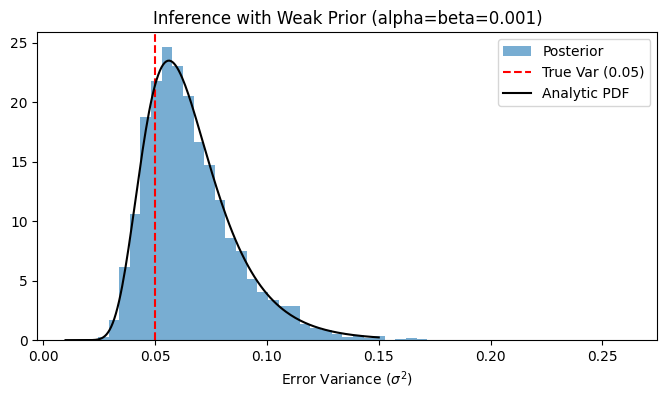

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# 1. Setup Data (Seed changed)
np.random.seed(0)
true_weights = np.array([1, 5, 10, 20, 50, 100, 200, 500]) 
true_mus = np.repeat(true_weights, 3) 

# True precision is 0.05
true_sigma2 = 0.05
readings = np.random.normal(true_mus, np.sqrt(true_sigma2))
errors = readings - true_mus

# 2. Analytic Posterior with Weak Priors
# We set these close to 0 to minimize their influence
alpha_prior = 0.001
beta_prior = 0.001

alpha_post = alpha_prior + len(errors) / 2.0
beta_post = beta_prior + np.sum(errors**2) / 2.0

# 3. Sampling
posterior_samples = invgamma.rvs(alpha_post, scale=beta_post, size=5000)

# 4. Visualization
plt.figure(figsize=(8, 4))
plt.hist(posterior_samples, bins=50, density=True, alpha=0.6, label='Posterior')
plt.axvline(true_sigma2, color='red', linestyle='--', label=f'True Var ({true_sigma2})')

# Analytic PDF
x = np.linspace(0.01, 0.15, 200)
plt.plot(x, invgamma.pdf(x, alpha_post, scale=beta_post), 'k-', label='Analytic PDF')

plt.title("Inference with Weak Prior (alpha=beta=0.001)")
plt.xlabel("Error Variance ($\sigma^2$)")
plt.legend()
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_72294/1896235219.py:44: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Variance $\sigma^2$ / Squared Error Value")


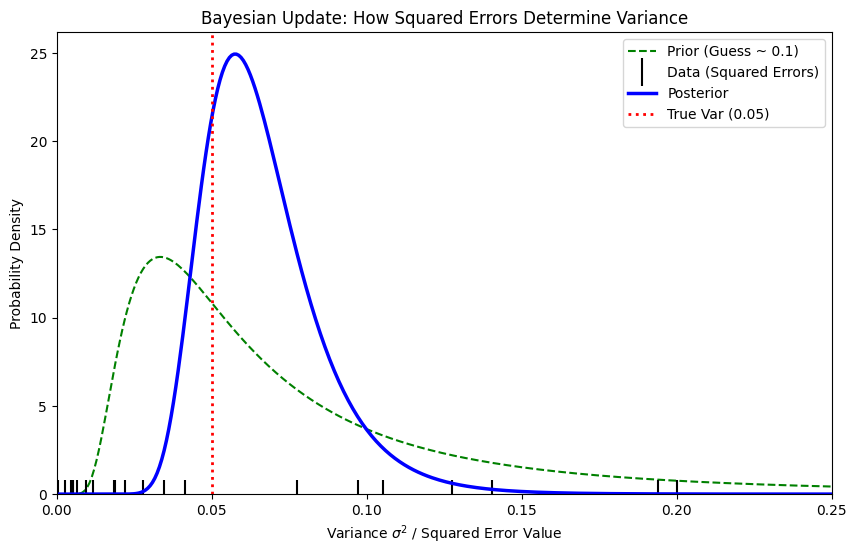

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma

# 1. Setup Data
np.random.seed(2026)
true_weights = np.array([1, 5, 10, 20, 50, 100, 200, 500]) 
true_mus = np.repeat(true_weights, 3) 
true_sigma2 = 0.05
readings = np.random.normal(true_mus, np.sqrt(true_sigma2))

# The "Data" for variance inference is the Squared Error
squared_errors = (readings - true_mus)**2

# 2. Inference
# Using a visible Prior: centered at 0.1, but very flat/uncertain
alpha_prior = 2.0
beta_prior = 0.1

alpha_post = alpha_prior + len(squared_errors) / 2.0
beta_post = beta_prior + np.sum(squared_errors) / 2.0

# 3. Visualization
plt.figure(figsize=(10, 6))
x = np.linspace(0.0, 0.3, 400)

# A. The Prior PDF
plt.plot(x, invgamma.pdf(x, alpha_prior, scale=beta_prior), 
         'g--', label='Prior (Guess ~ 0.1)')

# B. The Data (Rug Plot of Squared Errors)
# We plot these as vertical ticks on the x-axis
plt.plot(squared_errors, np.zeros_like(squared_errors), 
         '|k', markersize=20, markeredgewidth=1.5, label='Data (Squared Errors)')

# C. The Posterior PDF
plt.plot(x, invgamma.pdf(x, alpha_post, scale=beta_post), 
         'b-', linewidth=2.5, label='Posterior')

# D. The Truth
plt.axvline(true_sigma2, color='red', linestyle=':', linewidth=2, label=f'True Var ({true_sigma2})')

plt.title("Bayesian Update: How Squared Errors Determine Variance")
plt.xlabel("Variance $\sigma^2$ / Squared Error Value")
plt.ylabel("Probability Density")
plt.legend()
plt.ylim(bottom=0) # Keep y-axis clean
plt.xlim(0, 0.25)
plt.show()

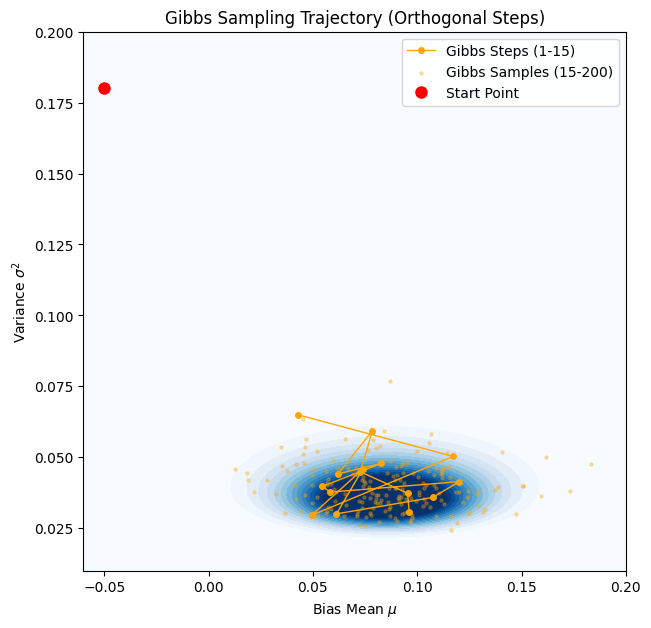

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import invgamma, norm

# --- 1. Data & Exact Parameters (Same as before) ---
def scale_measurements(weights=np.array([1, 5, 10, 20, 50, 100, 200, 500]),
                       reps_per_weight=5, mean=0.1, variance=0.05, seed=0):
    x = np.repeat(weights, reps_per_weight)
    rng = np.random.default_rng(seed)
    y = rng.normal(x * (1 + mean), x * np.sqrt(variance))
    return x, y

# Generate Data
x_data, y_data = scale_measurements()
rel_errors = (y_data - x_data) / x_data
n = len(rel_errors)
mle_mu = np.mean(rel_errors)

# Prior Parameters
mu_0, nu_0 = 0.0, 1.0
alpha_0, beta_0 = 2.0, 0.2

# --- 2. The Gibbs Sampler ---
def gibbs_sampler(iterations, start_mu, start_sig2, data):
    n = len(data)
    y_bar = np.mean(data)
    
    # Storage
    samples_mu = np.zeros(iterations)
    samples_sig2 = np.zeros(iterations)
    
    # Initialization
    current_mu = start_mu
    current_sig2 = start_sig2
    
    rng = np.random.default_rng(42)
    
    for i in range(iterations):
        # A. Update Variance (given current mean)
        # alpha_n is fixed: alpha_0 + n/2
        # beta_n changes: beta_0 + SSE_current / 2
        sse_current = np.sum((data - current_mu)**2)
        
        post_alpha = alpha_0 + n / 2.0
        post_beta = beta_0 + 0.5 * sse_current
        
        current_sig2 = invgamma.rvs(post_alpha, scale=post_beta, random_state=rng)
        
        # B. Update Mean (given current variance)
        # Precision (1/variance) changes based on current_sig2
        post_precision = (nu_0 + n) / current_sig2
        post_variance_mu = 1.0 / post_precision
        
        post_mean_mu = (nu_0 * mu_0 + n * y_bar) / (nu_0 + n)
        
        current_mu = rng.normal(post_mean_mu, np.sqrt(post_variance_mu))
        
        # Store
        samples_mu[i] = current_mu
        samples_sig2[i] = current_sig2
        
    return samples_mu, samples_sig2

# Run Sampler
# We start FAR away to visualize the "Burn-in" process
init_mu = -0.05 
init_sig2 = 0.18 
n_iter = 200

gibbs_mu, gibbs_sig2 = gibbs_sampler(n_iter, init_mu, init_sig2, rel_errors)

# --- 3. Visualization ---
# Calculate Exact Posterior for Background
nu_n = nu_0 + n
alpha_n = alpha_0 + n / 2.0
mu_n = (nu_0 * mu_0 + n * mle_mu) / nu_n
sse_exact = np.sum((rel_errors - mle_mu)**2)
beta_n = beta_0 + 0.5 * sse_exact + (n * nu_0 / nu_n) * 0.5 * (mle_mu - mu_0)**2

def nig_pdf(mu, sig2):
    if sig2 <= 0: return 0.0
    return invgamma.pdf(sig2, alpha_n, scale=beta_n) * norm.pdf(mu, loc=mu_n, scale=np.sqrt(sig2 / nu_n))

mu_grid = np.linspace(-0.06, 0.20, 100)
sig2_grid = np.linspace(0.01, 0.20, 100)
X, Y = np.meshgrid(mu_grid, sig2_grid)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = nig_pdf(X[i,j], Y[i,j])

# Plot
plt.figure(figsize=(7, 7))

# A. Background Exact Posterior
z_max = Z.max()
plt.contourf(X, Y, Z, levels=np.linspace(z_max*0.05, z_max*0.6, 15), cmap='Blues', extend='both')

# B. Gibbs Trajectory
# Plot first 15 steps clearly to show the "Zig-Zag" orthogonal moves
plt.plot(gibbs_mu[:15], gibbs_sig2[:15], 'o-', color='orange', lw=1, markersize=4, label='Gibbs Steps (1-15)')
# Plot the rest as a cloud
plt.scatter(gibbs_mu[15:], gibbs_sig2[15:], color='orange', s=5, alpha=0.3, label='Gibbs Samples (15-200)')

# Start Point
plt.plot(init_mu, init_sig2, 'ro', markersize=8, label='Start Point')

plt.title('Gibbs Sampling Trajectory (Orthogonal Steps)')
plt.xlabel(r'Bias Mean $\mu$')
plt.ylabel(r'Variance $\sigma^2$')
plt.legend(loc='upper right')
plt.xlim(-0.06, 0.20)
plt.ylim(0.01, 0.20)
plt.show()